# Experiments

1. Cencerrado et al posits that the last token of the question has intermediate layer activations that possess sufficient information for predicting eventual answer correctness which can be extracted via a Linear Probe. Let's test this!

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-Math-1.5B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [2]:
# Load model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None
)
if DEVICE != "cuda":
    model = model.to(DEVICE)
model.eval()
print(f"Loaded on {DEVICE}, layers: {len(model.model.layers)}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded on mps, layers: 28


In [4]:
print(model.model)

Qwen2Model(
  (embed_tokens): Embedding(151936, 1536)
  (layers): ModuleList(
    (0-27): 28 x Qwen2DecoderLayer(
      (self_attn): Qwen2Attention(
        (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
        (k_proj): Linear(in_features=1536, out_features=256, bias=True)
        (v_proj): Linear(in_features=1536, out_features=256, bias=True)
        (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
        (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
        (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((1536,), eps=1e-06)
  (rotary_emb): Qwen2RotaryEmbedding()
)


In [5]:
# Hook for capturing activations
class ActivationHook:
    def __init__(self):
        self.activations = []  # Store activation at each generation step
    
    def __call__(self, module, input, output):
        # output shape: (batch, seq_len, hidden_dim)
        # Take last token's activation
        if isinstance(output, tuple):
            output = output[0]
        self.activations.append(output[:, -1, :].detach().cpu())
    
    def clear(self):
        self.activations = []

In [6]:
# Register hooks on selected layers
def register_hooks(model, layer_indices):
    hooks = {}
    handles = []
    for idx in layer_indices:
        hook = ActivationHook()
        handle = model.model.layers[idx].register_forward_hook(hook)
        hooks[idx] = hook
        handles.append(handle)
    return hooks, handles

def remove_hooks(handles):
    for h in handles:
        h.remove()

In [14]:
# Generate with activation + entropy capture
def generate_with_tracking(prompt, max_new_tokens=512, layer_indices=[13]):
    hooks, handles = register_hooks(model, layer_indices)
    
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_len = inputs.input_ids.shape[1]
    
    entropies = []
    generated_ids = inputs.input_ids.clone()
    
    # Clear hooks before generation
    for hook in hooks.values():
        hook.clear()
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(generated_ids)
            logits = outputs.logits[:, -1, :]
            
            # Compute entropy
            probs = torch.softmax(logits, dim=-1)
            entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=-1).item()
            entropies.append(entropy)
            
            # Sample next token
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            generated_ids = torch.cat([generated_ids, next_token], dim=-1)
            
            # Stop on EOS
            if next_token.item() == tokenizer.eos_token_id:
                break
    
    remove_hooks(handles)
    
    # Stack activations: (num_tokens, hidden_dim) per layer
    activations = {layer: torch.cat(hook.activations, dim=0) for layer, hook in hooks.items()}
    output_text = tokenizer.decode(generated_ids[0, input_len:], skip_special_tokens=True)
    
    return output_text, entropies, activations

In [22]:
from datasets import load_dataset

SYSTEM_PROMPT = "Answer the following trivia question. Give a short, direct answer."

def format_prompt(question):
    """Format using chat template."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def get_prompt_activation(prompt, layer_indices=[13]):
    """Single forward pass on prompt to get last-token activation."""
    hooks, handles = register_hooks(model, layer_indices)
    for hook in hooks.values():
        hook.clear()
    
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        model(**inputs)
    
    remove_hooks(handles)
    return {layer: hook.activations[0].squeeze(0) for layer, hook in hooks.items()}


def generate_response(prompt, max_new_tokens=128):
    """Generate response without hooks."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(
            inputs.input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(output_ids[0, inputs.input_ids.shape[1]:], skip_special_tokens=True)


def check_trivia_answer(response, answer_data):
    """Check if response contains any valid answer alias."""
    response_lower = response.lower()
    # TriviaQA has 'value' (main answer) and 'aliases' (acceptable alternatives)
    valid_answers = [answer_data['value'].lower()]
    valid_answers.extend([a.lower() for a in answer_data.get('aliases', [])])
    return any(ans in response_lower for ans in valid_answers)


def generate_activation_correctness_pairs(n_problems=50, layer_indices=[13]):
    """Generate (activation, is_correct) pairs from TriviaQA."""
    dataset = load_dataset("trivia_qa", "rc", split="validation")
    
    pairs = []
    for i in range(min(n_problems, len(dataset))):
        problem = dataset[i]
        prompt = format_prompt(problem['question'])
        
        # Pass 1: Get activation at prompt end
        activation = get_prompt_activation(prompt, layer_indices)
        
        # Pass 2: Generate and check correctness
        response = generate_response(prompt)
        is_correct = check_trivia_answer(response, problem['answer'])
        
        pairs.append({
            'activation': activation,
            'is_correct': is_correct,
            'response': response,
            'ground_truth': problem['answer']['value'],
            'question': problem['question']
        })
        print(f"Problem {i+1}: {'✓' if is_correct else '✗'} | GT: {problem['answer']['value'][:30]}")
    
    return pairs

In [24]:
# Collect activation-correctness pairs
pairs = generate_activation_correctness_pairs(n_problems=50, layer_indices=[13])

# Separate correct vs incorrect
correct_acts = torch.stack([p['activation'][13] for p in pairs if p['is_correct']])
incorrect_acts = torch.stack([p['activation'][13] for p in pairs if not p['is_correct']])

print(f"\nCorrect: {len(correct_acts)}, Incorrect: {len(incorrect_acts)}")
print(f"Accuracy: {len(correct_acts) / len(pairs) * 100:.1f}%")

KeyboardInterrupt: 

In [21]:
pairs

[{'question': "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?",
  'activation': {13: tensor([-0.3636, -0.3251,  1.0482,  ..., -0.0705, -1.3408, -2.0304])},
  'is_correct': True,
  'response': " $24\n\nStep by step solution:\n1. Calculate the total number of eggs laid by the ducks each day:\n   \\[\n   16 \\text{ eggs/day}\n   \\]\n\n2. Calculate the total number of eggs Janet eats for breakfast each day:\n   \\[\n   3 \\text{ eggs/day}\n   \\]\n\n3. Calculate the total number of eggs Janet bakes for her friends each day:\n   \\[\n   4 \\text{ eggs/day}\n   \\]\n\n4. Calculate the total number of eggs Janet sells at the farmers' market each day by subtracting the eggs she eats and bakes from the total eggs laid:\n   \\[\n   16 - 3 - 4 = 9 \\text{ eggs/day}\

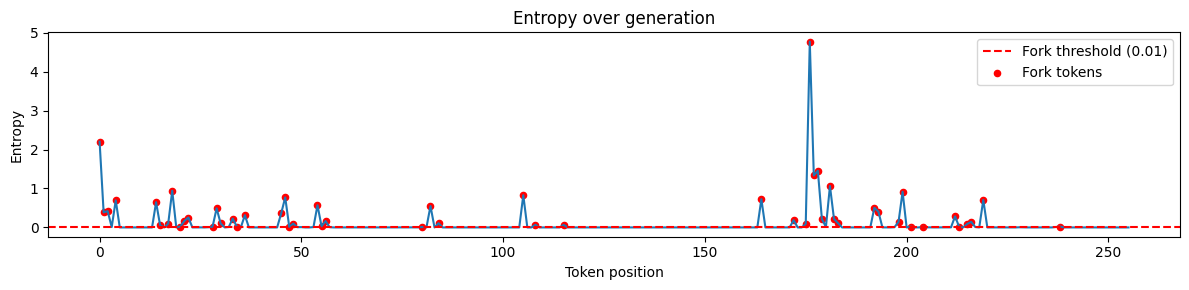

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Identify forking tokens (high entropy)
threshold = np.percentile(entropies, 80)  # Top 20% entropy
fork_indices = [i for i, e in enumerate(entropies) if e >= threshold]
non_fork_indices = [i for i, e in enumerate(entropies) if e < threshold]

plt.figure(figsize=(12, 3))
plt.plot(entropies)
plt.axhline(threshold, color='r', linestyle='--', label=f'Fork threshold ({threshold:.2f})')
plt.scatter(fork_indices, [entropies[i] for i in fork_indices], color='red', s=20, label='Fork tokens')
plt.xlabel('Token position')
plt.ylabel('Entropy')
plt.legend()
plt.title('Entropy over generation')
plt.tight_layout()
plt.show()

In [13]:
# Compare activations at fork vs non-fork positions
layer = 13  # Middle layer

fork_acts = activations[layer][fork_indices]
non_fork_acts = activations[layer][non_fork_indices]

print(f"Fork activations: {fork_acts.shape}")
print(f"Non-fork activations: {non_fork_acts.shape}")

# Basic stats
print(f"\nMean activation norm (fork): {fork_acts.norm(dim=1).mean():.2f}")
print(f"Mean activation norm (non-fork): {non_fork_acts.norm(dim=1).mean():.2f}")

Fork activations: torch.Size([52, 1536])
Non-fork activations: torch.Size([204, 1536])

Mean activation norm (fork): 85.45
Mean activation norm (non-fork): 86.87


In [ ]:
# Direction calculator (minimal version)
def compute_correctness_direction(correct_acts, incorrect_acts):
    """Compute direction from incorrect to correct centroid."""
    centroid_correct = correct_acts.mean(dim=0)
    centroid_incorrect = incorrect_acts.mean(dim=0)
    direction = centroid_correct - centroid_incorrect
    return direction / direction.norm()

def project_onto_direction(activations, direction):
    """Project activations onto direction, return scalar scores."""
    return (activations @ direction).numpy()

In [ ]:
# TODO: Run multiple rollouts, separate correct vs incorrect
# Then: direction = compute_correctness_direction(correct_fork_acts, incorrect_fork_acts)
# Then: scores = project_onto_direction(all_acts, direction)
# Analysis: Do scores differ at fork vs non-fork? Do they correlate with entropy?